<a href="https://colab.research.google.com/github/springboardmentor2468a-lab/Projects_2/blob/vinayvenkat/task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

splitting the data

DAY DATA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [20]:
day = pd.read_csv('/content/drive/MyDrive/data set/day.csv')

In [21]:
day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [22]:
day = day.drop(columns=["instant", "dteday", "casual", "registered"])

In [23]:
day.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


In [24]:
X_day = day.drop("cnt", axis=1)
Y_day = day["cnt"]

In [25]:
X_train_day, X_test_day, y_train_day, y_test_day = train_test_split(
    X_day, y_day, test_size=0.2, random_state=42)

In [51]:
print(X_day)

     season  yr  mnth  holiday  weekday  workingday  weathersit      temp  \
0         1   0     1        0        6           0           2  0.344167   
1         1   0     1        0        0           0           2  0.363478   
2         1   0     1        0        1           1           1  0.196364   
3         1   0     1        0        2           1           1  0.200000   
4         1   0     1        0        3           1           1  0.226957   
..      ...  ..   ...      ...      ...         ...         ...       ...   
726       1   1    12        0        4           1           2  0.254167   
727       1   1    12        0        5           1           2  0.253333   
728       1   1    12        0        6           0           2  0.253333   
729       1   1    12        0        0           0           1  0.255833   
730       1   1    12        0        1           1           2  0.215833   

        atemp       hum  windspeed  
0    0.363625  0.805833   0.160446  
1

In [27]:
print(Y_day)

0       985
1       801
2      1349
3      1562
4      1600
       ... 
726    2114
727    3095
728    1341
729    1796
730    2729
Name: cnt, Length: 731, dtype: int64


In [28]:
regressor = RandomForestRegressor(n_estimators=100)

In [31]:
regressor.fit(X_train_day, y_train_day)

RandomForestRegressor()

In [33]:
test_day_data_prediction = regressor.predict(X_test_day)

In [34]:
print(test_day_data_prediction)

[6850.67 1533.03 3452.49 4703.38 7499.48 7323.6  1486.99 2372.87 7305.47
 6422.47 2025.26 2905.71 5027.61 4889.71 2066.06 2147.54 2315.63 7819.99
 4942.97 2445.44 7487.48 5443.21 5639.6  1716.48 1731.53 4734.65 2008.32
 7156.71 3103.03 5528.91 3046.27 4018.68 6530.62 7599.99 6235.83 5249.82
 7407.8  6345.76 3256.3   941.21 3808.86 3103.24 7240.12 4443.12 6949.64
 2332.22 4460.66 5651.17 6598.07 4250.85 4106.84 2987.14 2175.59 4031.56
 4636.11 4201.92 3951.48 3781.74 4263.11 6547.87 6327.37 6880.21 2004.3
 7468.76 6499.69 6156.88 5961.34 4021.31 1730.57 7314.59 3824.27 1854.95
 3369.71 3953.26 4328.23 3737.7  4637.4  4562.6  1363.77 4131.62 2271.93
 1964.05 5118.66 4157.28 3654.49 3348.24 4092.68 3707.16 3550.61 3292.11
 1342.04 7012.   5591.83 5730.94 2469.62 2357.34 4871.45 2575.62 3804.18
 4878.16 7526.27 4157.87 6754.4  1956.09 2369.48 5193.74 2300.71 2957.93
 6511.95 1329.92 4089.68 7277.38 3812.83 7769.42 5907.21 4186.31 1531.76
 3223.61 5133.03 2553.2  6634.91 2549.9  3496.49 146

In [37]:
error_score = metrics.r2_score(y_test_day, test_day_data_prediction)
print("R squared error : ", error_score)

R squared error :  0.8843757527051275


In [40]:
y_test_day = list(y_test_day)

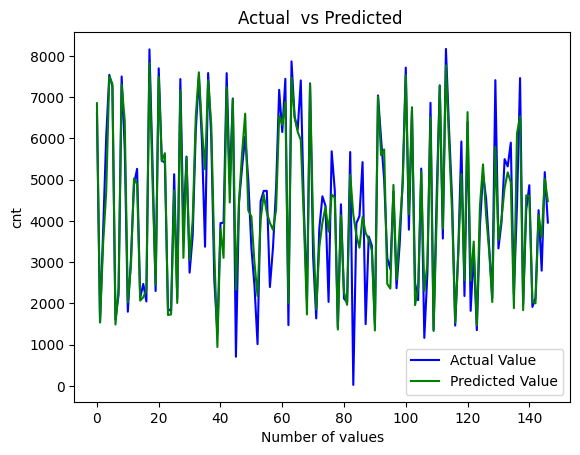

In [42]:
plt.plot(y_test_day, color='blue', label = 'Actual Value')
plt.plot(test_day_data_prediction, color='green', label='Predicted Value')
plt.title('Actual  vs Predicted ')
plt.xlabel('Number of values')
plt.ylabel('cnt')
plt.legend()
plt.show()

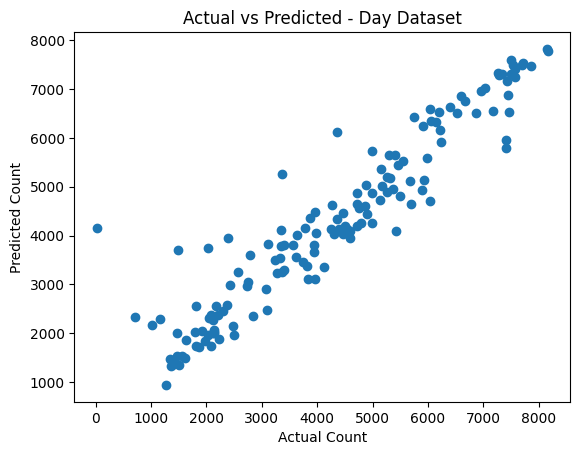

In [44]:
plt.figure()
plt.scatter(y_test_day,test_day_data_prediction)
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted - Day Dataset")
plt.show()

HOUR DATA

In [45]:
hour=pd.read_csv('/content/drive/MyDrive/data set/hour.csv')

In [46]:
hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [47]:
hour = hour.drop(columns=["instant", "dteday", "casual", "registered"])

In [48]:
hour.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [49]:
X_hour = hour.drop("cnt", axis=1)
y_hour = hour["cnt"]


In [50]:
X_train_hour, X_test_hour, y_train_hour, y_test_hour = train_test_split(
    X_hour, y_hour, test_size=0.2, random_state=42)

In [52]:
print(X_hour)

       season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
0           1   0     1   0        0        6           0           1  0.24   
1           1   0     1   1        0        6           0           1  0.22   
2           1   0     1   2        0        6           0           1  0.22   
3           1   0     1   3        0        6           0           1  0.24   
4           1   0     1   4        0        6           0           1  0.24   
...       ...  ..   ...  ..      ...      ...         ...         ...   ...   
17374       1   1    12  19        0        1           1           2  0.26   
17375       1   1    12  20        0        1           1           2  0.26   
17376       1   1    12  21        0        1           1           1  0.26   
17377       1   1    12  22        0        1           1           1  0.26   
17378       1   1    12  23        0        1           1           1  0.26   

        atemp   hum  windspeed  
0      0.2879  0.8

In [53]:
print(y_hour)

0         16
1         40
2         32
3         13
4          1
        ... 
17374    119
17375     89
17376     90
17377     61
17378     49
Name: cnt, Length: 17379, dtype: int64


In [54]:
regressor = RandomForestRegressor(n_estimators=100)

In [63]:
regressor.fit(X_train_hour, y_train_hour)

RandomForestRegressor()

In [65]:
test_hour_data_prediction = regressor.predict(X_test_hour)

In [58]:
print(test_hour_data_prediction)

[384.06 101.53  12.29 ...  78.74 362.89 245.6 ]


In [59]:
# R squared error
error_score = metrics.r2_score(y_test_hour, test_hour_data_prediction)
print("R squared error : ", error_score)

R squared error :  0.9438410201798365


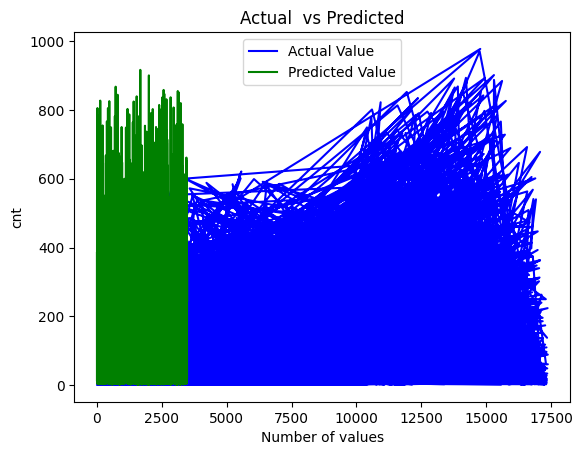

In [60]:
plt.plot(y_test_hour, color='blue', label = 'Actual Value')
plt.plot(test_hour_data_prediction, color='green', label='Predicted Value')
plt.title('Actual  vs Predicted')
plt.xlabel('Number of values')
plt.ylabel('cnt')
plt.legend()
plt.show()

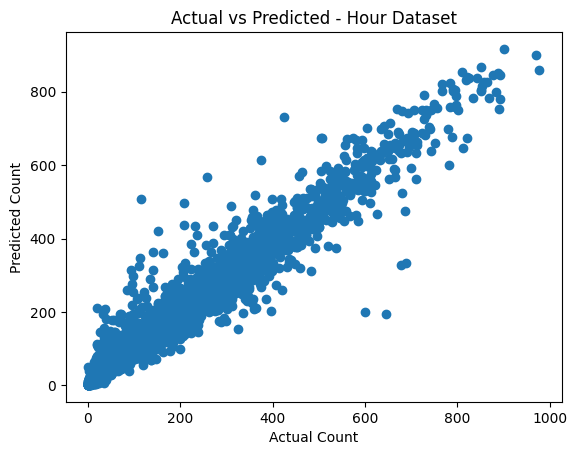

In [61]:
plt.figure()
plt.scatter(y_test_hour,test_hour_data_prediction )
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted - Hour Dataset")
plt.show()
